In [65]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [66]:
import os
import sys
import gymnasium as gym
import yaml
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath("../envs"))
sys.path.append(os.path.abspath("../models"))
sys.path.append(os.path.abspath("../src"))

from env1 import ConstantRewardEnv
from env2 import RandomObsBinaryRewardEnv
from env3 import TwoStepDelayedRewardEnv

from utils_dqn import *
from utils import load_from_tensorboard

In [67]:
with open("../config/dqn_config.yaml", "r") as f:
    config = yaml.safe_load(f)

## DQN

### env 1

In [68]:
gym.register(
    id="gymnasium_env/ConstantReward-v0",
    entry_point=ConstantRewardEnv,
)

env1 = gym.make("gymnasium_env/ConstantReward-v0")

print(env1.action_space)
print(env1.observation_space)

Discrete(1)
Discrete(1)


c:\Users\Lucio\miniconda3\envs\RL\Lib\site-packages\gymnasium\envs\registration.py:636: UserWarning: WARN: Overriding environment gymnasium_env/ConstantReward-v0 already in registry.
  logger.warn(f"Overriding environment {new_spec.id} already in registry.")


In [69]:
experiment_folder = "env1"
episodes = config[experiment_folder]["episodes"]
buffer_size = config[experiment_folder]["buffer_size"]
max_steps = config[experiment_folder]["max_steps"]
gamma = config[experiment_folder]["gamma"]
alpha = config[experiment_folder]["alpha"]
target_update_freq = config[experiment_folder]["target_update_freq"]
min_epsilon = config[experiment_folder]["min_epsilon"]
max_epsilon = config[experiment_folder]["max_epsilon"]
decay_rate = config[experiment_folder]["decay_rate"]
batch_size = config[experiment_folder]["batch_size"]
seed = config["xtra"]["seed"]


model_1_path, _ = train_dqn(experiment_folder, env1, episodes, buffer_size, max_steps,
        gamma, alpha, target_update_freq, min_epsilon, max_epsilon, decay_rate, batch_size, seed, log_q_values=True)

Training DQN:   0%|          | 0/500 [00:00<?, ?it/s]

In [70]:
env1 = gym.make("gymnasium_env/ConstantReward-v0")

success_rate, unique_q_values = evaluate_dqn_env1(model_1_path, env1, episodes=100, seed=seed)
print(f"Success rate: {success_rate:.2f}")
print(f"Unique Q-values: {len(unique_q_values)}, {unique_q_values}")

Success rate: 1.00
Unique Q-values: 1, {np.float32(0.99999994)}


### env2

In [71]:
gym.register(
    id="gymnasium_env/RandomObsBinaryReward-v0",
    entry_point=RandomObsBinaryRewardEnv,
)

env2 = gym.make("gymnasium_env/RandomObsBinaryReward-v0")

print(env2.action_space)
print(env2.observation_space)

Discrete(1)
Box(-1.0, 1.0, (1,), float32)


c:\Users\Lucio\miniconda3\envs\RL\Lib\site-packages\gymnasium\envs\registration.py:636: UserWarning: WARN: Overriding environment gymnasium_env/RandomObsBinaryReward-v0 already in registry.
  logger.warn(f"Overriding environment {new_spec.id} already in registry.")


In [72]:
experiment_folder = "env2"
episodes = config[experiment_folder]["episodes"]
buffer_size = config[experiment_folder]["buffer_size"]
max_steps = config[experiment_folder]["max_steps"]
gamma = config[experiment_folder]["gamma"]
alpha = config[experiment_folder]["alpha"]
target_update_freq = config[experiment_folder]["target_update_freq"]
min_epsilon = config[experiment_folder]["min_epsilon"]
max_epsilon = config[experiment_folder]["max_epsilon"]
decay_rate = config[experiment_folder]["decay_rate"]
batch_size = config[experiment_folder]["batch_size"]
seed = config["xtra"]["seed"]

model_2_path, _ = train_dqn(experiment_folder, env2, episodes, buffer_size, max_steps,
    gamma, alpha, target_update_freq, min_epsilon, max_epsilon, decay_rate, batch_size, seed, log_q_values=True)

Training DQN:   0%|          | 0/500 [00:00<?, ?it/s]

In [73]:
env2 = gym.make("gymnasium_env/RandomObsBinaryReward-v0")

mse, obs_q = evaluate_dqn_env2(model_2_path, env2, episodes=100, seed=seed)
print(f"mse: {mse:.4f}")
print(obs_q)

mse: 0.0000
{-1.0: {-1.0}, 1.0: {1.0}}


### Env 3

In [74]:
gym.register(
    id="gymnasium_env/TwoStepDelayedReward-v0",
    entry_point=TwoStepDelayedRewardEnv,
)

env3 = gym.make("gymnasium_env/TwoStepDelayedReward-v0")

print(env3.action_space)
print(env3.observation_space)

Discrete(1)
Discrete(2)


c:\Users\Lucio\miniconda3\envs\RL\Lib\site-packages\gymnasium\envs\registration.py:636: UserWarning: WARN: Overriding environment gymnasium_env/TwoStepDelayedReward-v0 already in registry.
  logger.warn(f"Overriding environment {new_spec.id} already in registry.")


In [75]:
experiment_folder = "env3"
episodes = config[experiment_folder]["episodes"]
buffer_size = config[experiment_folder]["buffer_size"]
max_steps = config[experiment_folder]["max_steps"]
gamma = config[experiment_folder]["gamma"]
alpha = config[experiment_folder]["alpha"]
target_update_freq = config[experiment_folder]["target_update_freq"]
min_epsilon = config[experiment_folder]["min_epsilon"]
max_epsilon = config[experiment_folder]["max_epsilon"]
decay_rate = config[experiment_folder]["decay_rate"]
batch_size = config[experiment_folder]["batch_size"]
seed = config["xtra"]["seed"]


model_3_path, _ = train_dqn(experiment_folder, env3, episodes, buffer_size, max_steps,
    gamma, alpha, target_update_freq, min_epsilon, max_epsilon, decay_rate, batch_size, seed, log_q_values=True)

Training DQN:   0%|          | 0/500 [00:00<?, ?it/s]

In [76]:
env3 = gym.make("gymnasium_env/TwoStepDelayedReward-v0")

success_rate, mse, obs_q = evaluate_dqn_env3(model_3_path, env3, gamma, episodes=100, seed=seed)
print(f"success rate: {success_rate:.4f}")
print(f"mse: {mse:.4f}")
print(obs_q)

success rate: 1.0000
mse: 0.0000
{0: {0.99}, 1: {1.0}}


## Plots

### Env1

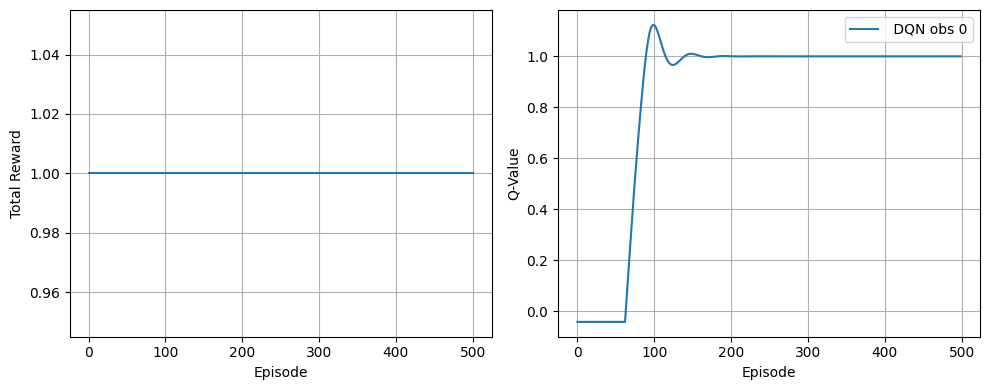

In [ ]:
folder_name = "dqn/env1"
path = Path(f"../runs/{folder_name}")
tag = "Reward/TotalSteps"
episodes, values = load_from_tensorboard(path, tag)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(episodes, values)
axes[0].set_xlabel("Episode")
axes[0].set_ylabel("Total Reward")
axes[0].grid(True)

path = Path(f"../runs/{folder_name}")
tag= "Q-values/Episode/state_0_action_0"
episodes, values = load_from_tensorboard(path, tag)
axes[1].plot(episodes, values, label=" DQN obs 0")
axes[1].set_xlabel("Episode")
axes[1].set_ylabel("Q-Value")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()


### Env2

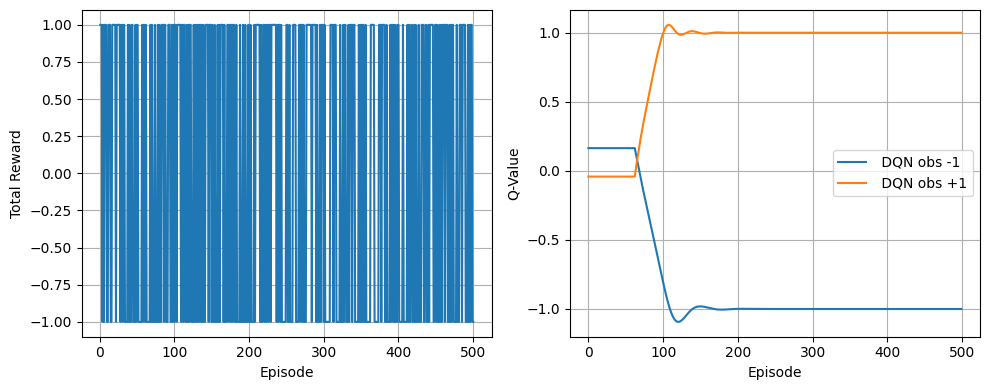

In [ ]:
folder_name = "dqn/env2"
path = Path(f"../runs/{folder_name}")
tag = "Reward/TotalSteps"
episodes, values = load_from_tensorboard(path, tag)

#plot it
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(episodes, values)
axes[0].set_xlabel("Episode")
axes[0].set_ylabel("Total Reward")
axes[0].grid(True)

path = Path(f"../runs/{folder_name}")
tag= "Q-values/Episode/obs_minus_1_action_0"

episodes, values = load_from_tensorboard(path, tag)

tag = "Q-values/Episode/obs_plus_1_action_0"
episodes2, values2 = load_from_tensorboard(path, tag)
axes[1].plot(episodes, values, label=" DQN obs -1")
axes[1].plot(episodes2, values2, label=" DQN obs +1")
axes[1].set_xlabel("Episode")
axes[1].set_ylabel("Q-Value")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

### env3

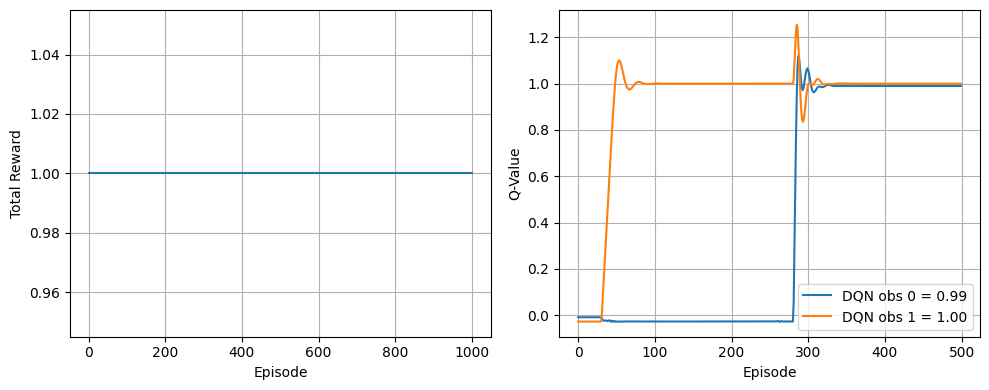

In [83]:
folder_name = "dqn/env3"
path = Path(f"../runs/{folder_name}")
tag = "Reward/TotalSteps"
episodes, values = load_from_tensorboard(path, tag)

#plot it
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(episodes, values)
axes[0].set_xlabel("Episode")
axes[0].set_ylabel("Total Reward")
axes[0].grid(True)

path = Path(f"../runs/{folder_name}")
tag= "Q-values/Episode/state_0_action_0"
episodes, values = load_from_tensorboard(path, tag)

tag = "Q-values/Episode/state_1_action_0"
episodes2, values2 = load_from_tensorboard(path, tag)
axes[1].plot(episodes, values, label= f"DQN obs 0 = {values[-1]:.2f}")
axes[1].plot(episodes2, values2, label= f"DQN obs 1 = {values2[-1]:.2f}")
axes[1].set_xlabel("Episode")
axes[1].set_ylabel("Q-Value")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()